In [9]:
import numpy as np
data = np.load('/data/pre_student/GJ/DepthCAD/pred_IQs.npy')
print(data)
print(data.shape) # 查看数组的形状
print(data.dtype) # 查看数组的数据类型


[[[-88.86693    -85.67003    -80.70204    ... -23.191393   -26.882856
   -39.34294   ]
  [-78.19576    -77.540794   -76.157326   ... -17.744423   -19.84301
   -27.00093   ]
  [-75.41102    -77.59426    -79.36536    ... -21.498266   -22.489637
   -26.622204  ]
  ...
  [-24.951355   -26.510815   -27.513325   ... -73.12752    -74.152306
   -79.53245   ]
  [-25.664251   -24.54144    -25.89817    ... -71.67945    -78.44973
   -89.49071   ]
  [-28.961393   -25.748907   -23.7929     ... -77.00389    -83.19272
   -98.958855  ]]

 [[ 34.88734     29.89707     28.760893   ... 196.21344    195.56738
   197.8286    ]
  [ 29.206451    28.55148     29.139618   ... 188.07083    188.25798
   189.00652   ]
  [ 30.186684    28.00344     26.733595   ... 188.02628    189.89763
   195.82358   ]
  ...
  [ 44.11043     44.89016     46.059757   ...  85.714584    87.34088
    86.32723   ]
  [ 43.174755    45.794647    47.017708   ...  86.18243     87.10474
    85.28017   ]
  [ 44.400043    44.945858    46.7949

In [2]:
import numpy as np
data = np.load('/data/pre_student/hcy/pbrt/gt/bathroom/1/104.npy')
print(data)
print(data.shape) # 查看数组的形状
print(data.dtype) # 查看数组的数据类型


[[[-1.72199995e+02 -1.79684623e+02 -1.84536558e+02 ... -7.07090907e+01
   -6.81218572e+01 -7.03349748e+01]
  [-1.61093450e+02 -1.97425452e+02 -2.05899425e+02 ... -7.29877395e+01
   -6.93161827e+01 -6.50577591e+01]
  [-2.04075410e+02 -1.54598000e+02 -1.78872702e+02 ... -7.15903747e+01
   -7.06514123e+01 -6.76818159e+01]
  ...
  [-3.10029552e+01 -3.31504391e+01 -4.14953275e+01 ... -1.14661350e+02
   -1.21108734e+02 -1.18206629e+02]
  [-3.80058862e+01 -3.77174892e+01 -3.56401762e+01 ... -1.11591148e+02
   -1.20666139e+02 -1.09164028e+02]
  [-3.41567305e+01 -3.22367579e+01 -3.96307721e+01 ... -1.08637194e+02
   -1.19517360e+02 -1.11905353e+02]]

 [[-6.17231670e-01  2.36123019e+00  5.53462836e+00 ... -3.49278377e+02
   -3.44096959e+02 -3.63447226e+02]
  [-4.21331186e-01  2.78691359e+00  6.37758762e+00 ... -3.56570107e+02
   -3.46209886e+02 -3.32346004e+02]
  [-3.36206496e-01  2.33298728e+00  5.71650260e+00 ... -3.45930394e+02
   -3.48964824e+02 -3.41845550e+02]
  ...
  [-3.43292787e+01 -3.6

数据形状: (6, 240, 320)
数据类型: float32


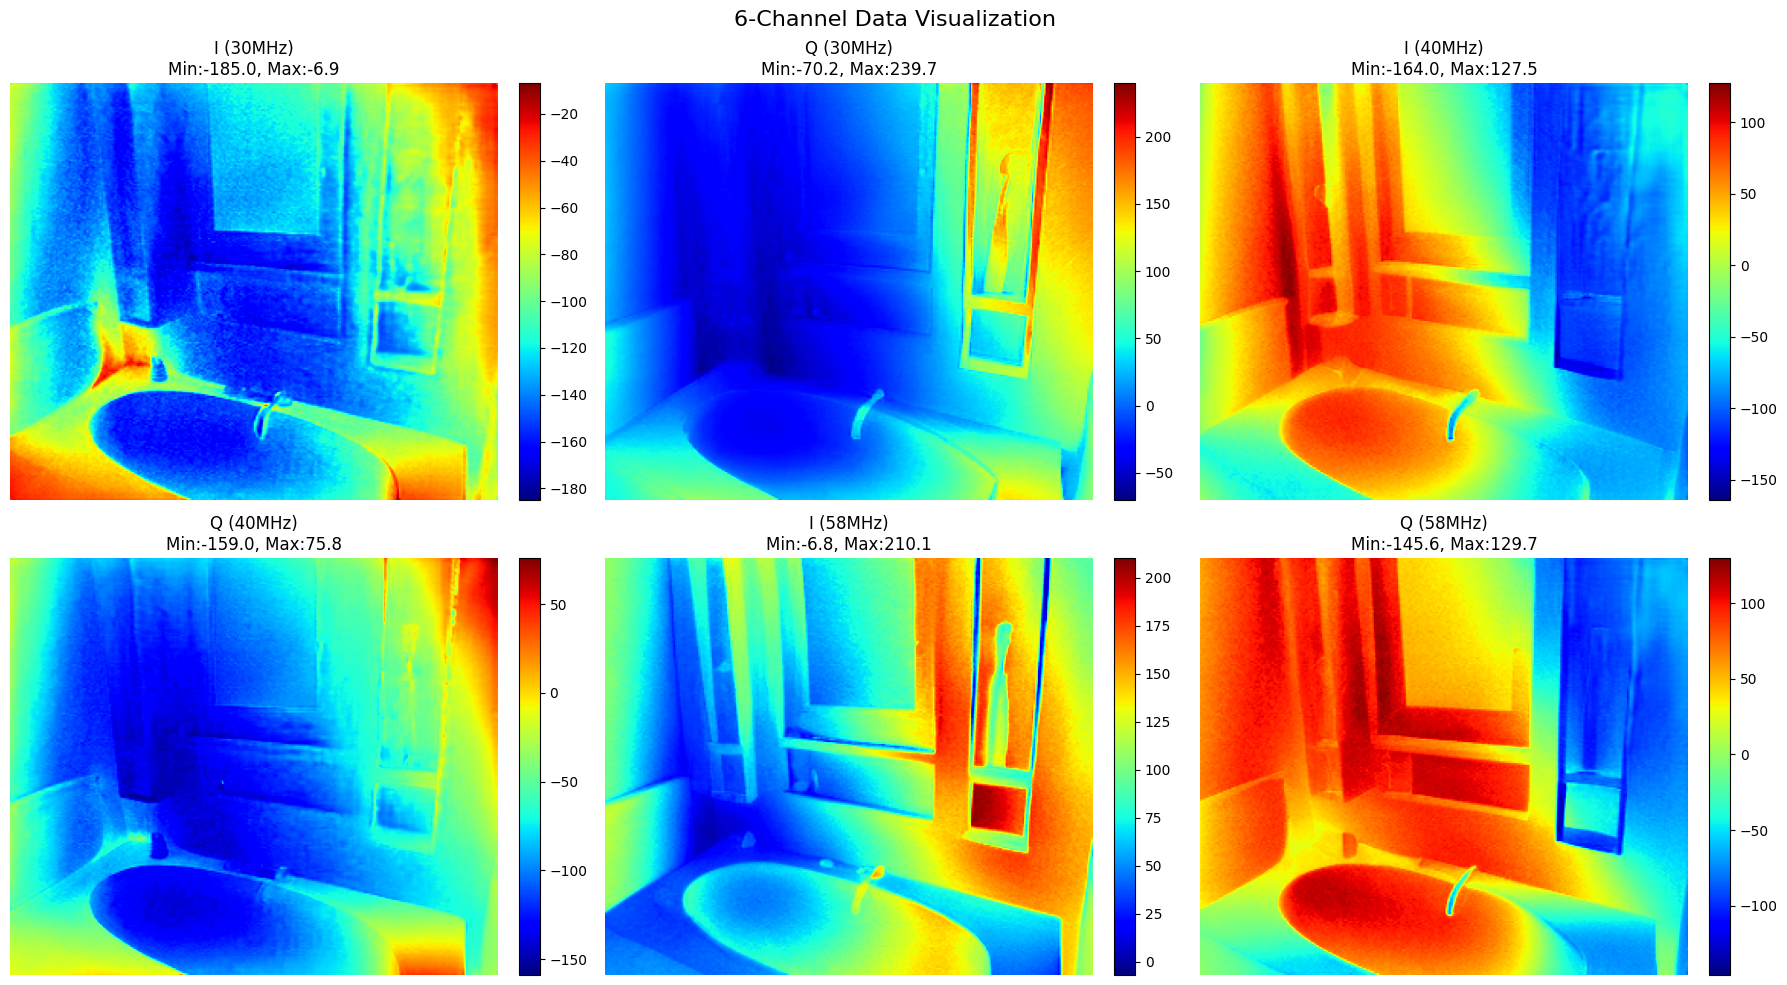

<Figure size 640x480 with 0 Axes>

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 加载数据
# 假设你的文件名为 data.npy
# data = np.load('your_file.npy')
data = np.load('/data/pre_student/GJ/DepthCAD/test/104_55000.npy')
# 这里使用你提供的数据形状做演示
# data = np.random.randn(6, 240, 320).astype(np.float32) 
# 实际使用时请取消上面注释，直接加载你的文件

print(f"数据形状: {data.shape}")
print(f"数据类型: {data.dtype}")

# 2. 创建画布：2行3列
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten() # 将 2x3 的数组展平，方便循环

# 3. 如果你知道这6个通道的具体含义（例如 I/Q 分量），可以在这里定义标题
# 根据你之前的 IQToDepth 上下文，顺序可能是：
channel_names = ["I (30MHz)", "Q (30MHz)", "I (40MHz)", "Q (40MHz)", "I (58MHz)", "Q (58MHz)"]
# 如果不确定，就用默认的
# channel_names = [f"Channel {i}" for i in range(6)]

# 4. 循环绘制每一张图
for i in range(6):
    # 取出第 i 个通道的数据 (240, 320)
    img_data = data[i]
    
    # 绘制热力图
    # cmap='jet' 或 'viridis' 能很好地表现数值高低（冷色低，暖色高）
    im = axes[i].imshow(img_data, cmap='jet', aspect='auto')
    
    # 设置标题
    axes[i].set_title(f"{channel_names[i]}\nMin:{img_data.min():.1f}, Max:{img_data.max():.1f}")
    
    # 关闭坐标轴刻度，让图片更清爽
    axes[i].axis('off')
    
    # 添加颜色条，方便看数值大小
    fig.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)

plt.suptitle("6-Channel Data Visualization", fontsize=16)
plt.tight_layout()
plt.show()

# 5. 如果想保存这张大图
plt.savefig('vis_6_channels.png', dpi=150)

In [4]:
from pbrt_dataset.preprocess import load_raw as load_raw_pbrt
from IQToDepth import IQ_to_depth
gt_file='/data/pre_student/hcy/pbrt/gt/bathroom/1/104.npy'
target_size=(240,320)
gt=load_raw_pbrt(gt_file, target_size=target_size, sqrt_in=True)
depth=IQ_to_depth(gt, corr_save_path=None, depth_save_path=None)
print(f"Output Depth Shape: {depth.shape}")
print(f"Output Depth Range: {depth.min():.4f}m - {depth.max():.4f}m")

Output Depth Shape: (240, 320)
Output Depth Range: 1.8944m - 3.5967m


In [5]:
from pbrt_dataset.preprocess import load_raw as load_raw_pbrt
from IQToDepth import IQ_to_depth
pred_IQs = np.load('/data/pre_student/GJ/DepthCAD/test/104_55000.npy')
depth = IQ_to_depth(pred_IQs, corr_save_path=None, depth_save_path=None)
print(f"Depth map shape: {depth.shape}")
print(f"Depth range: [{depth.min():.4f}, {depth.max():.4f}] meters")
out_file='predict_depth.npy'
# Save output
print(f"\nSaving depth to {out_file}...")
np.save(out_file, depth)
print("Done!")

Depth map shape: (240, 320)
Depth range: [1.7403, 7.5015] meters

Saving depth to predict_depth.npy...
Done!


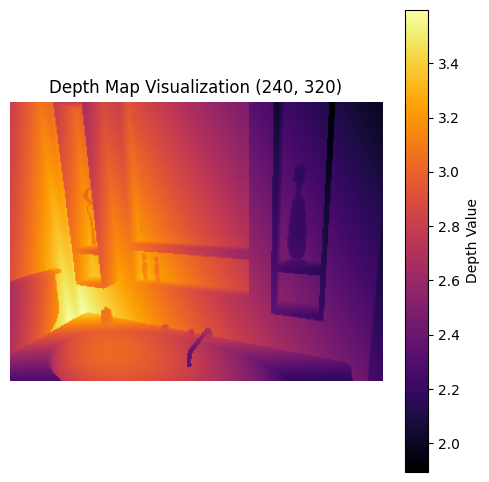

已保存为 depth_heatmap.png


In [5]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 假设这是你的数据加载过程
data = np.load('/data/pre_student/hcy/pbrt/gt_depth/bathroom/1/104.npy')
# 为了演示，我直接使用你提供的形状和大概数值范围生成模拟数据
# data = ... (你已经加载好的变量)

# 2. 检查数据中是否有无穷大 (inf) 或 NaN
# 深度图有时背景是无限远 (inf)，这会导致可视化失败，需要处理一下
if np.isinf(data).any():
    # 将 inf 替换为当前数据中的最大有限值，或者一个特定值
    max_val = data[~np.isinf(data)].max()
    data[np.isinf(data)] = max_val

# 3. 使用 Matplotlib 绘图
plt.figure(figsize=(6, 6))

# cmap 参数决定颜色风格：
# 'viridis' (默认，蓝绿黄), 'inferno' (黑红黄), 'plasma' (紫红黄), 'jet' (彩虹色)
# 'gray' (灰度)
plt.imshow(data, cmap='inferno') 
plt.colorbar(label='Depth Value') # 显示色条，告诉你颜色代表的数值
plt.title(f'Depth Map Visualization {data.shape}')
plt.axis('off') # 不显示坐标轴

# 4. 保存
plt.savefig('depth_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()
print("已保存为 depth_heatmap.png")

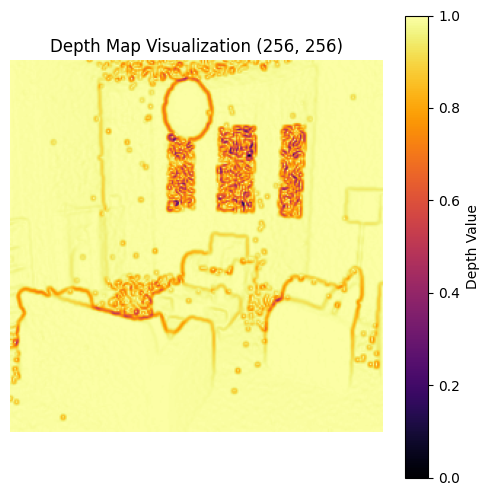

已保存为 depth_heatmap.png


In [8]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 假设这是你的数据加载过程
data = np.load('/data/pre_student/GJ/DepthCAD/pbrt_dataset/data/confidence/white-room/0/1.npy')
# 为了演示，我直接使用你提供的形状和大概数值范围生成模拟数据
# data = ... (你已经加载好的变量)

# 2. 检查数据中是否有无穷大 (inf) 或 NaN
# 深度图有时背景是无限远 (inf)，这会导致可视化失败，需要处理一下
if np.isinf(data).any():
    # 将 inf 替换为当前数据中的最大有限值，或者一个特定值
    max_val = data[~np.isinf(data)].max()
    data[np.isinf(data)] = max_val

# 3. 使用 Matplotlib 绘图
plt.figure(figsize=(6, 6))

# cmap 参数决定颜色风格：
# 'viridis' (默认，蓝绿黄), 'inferno' (黑红黄), 'plasma' (紫红黄), 'jet' (彩虹色)
# 'gray' (灰度)
plt.imshow(data, cmap='inferno') 
plt.colorbar(label='Depth Value') # 显示色条，告诉你颜色代表的数值
plt.title(f'Depth Map Visualization {data.shape}')
plt.axis('off') # 不显示坐标轴

# 4. 保存
plt.savefig('depth_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()
print("已保存为 depth_heatmap.png")

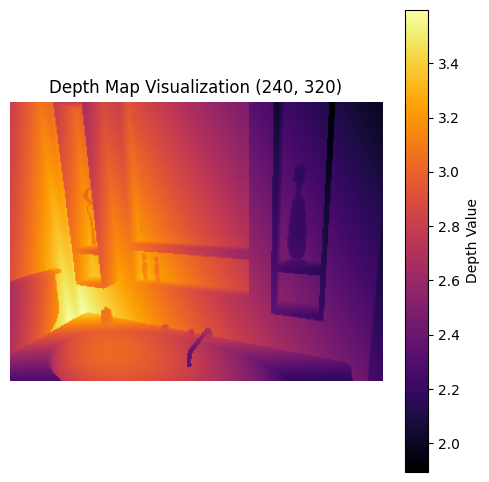

已保存为 depth_heatmap.png


In [9]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 假设这是你的数据加载过程
data = np.load('/data/pre_student/hcy/pbrt/gt_depth/bathroom/1/104.npy')
# 为了演示，我直接使用你提供的形状和大概数值范围生成模拟数据
# data = ... (你已经加载好的变量)

# 2. 检查数据中是否有无穷大 (inf) 或 NaN
# 深度图有时背景是无限远 (inf)，这会导致可视化失败，需要处理一下
if np.isinf(data).any():
    # 将 inf 替换为当前数据中的最大有限值，或者一个特定值
    max_val = data[~np.isinf(data)].max()
    data[np.isinf(data)] = max_val

# 3. 使用 Matplotlib 绘图
plt.figure(figsize=(6, 6))

# cmap 参数决定颜色风格：
# 'viridis' (默认，蓝绿黄), 'inferno' (黑红黄), 'plasma' (紫红黄), 'jet' (彩虹色)
# 'gray' (灰度)
plt.imshow(data, cmap='inferno') 
plt.colorbar(label='Depth Value') # 显示色条，告诉你颜色代表的数值
plt.title(f'Depth Map Visualization {data.shape}')
plt.axis('off') # 不显示坐标轴

# 4. 保存
plt.savefig('depth_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()
print("已保存为 depth_heatmap.png")

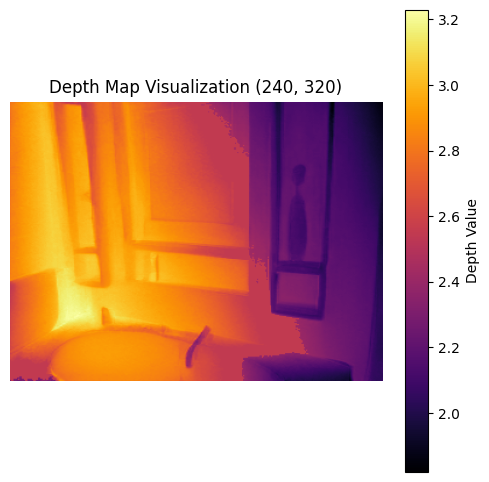

已保存为 depth_heatmap.png


In [5]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 假设这是你的数据加载过程
data = np.load('/data/pre_student/GJ/DepthCAD/pbrt/data_1212_55000/bathroom/1/104.npy')
# 为了演示，我直接使用你提供的形状和大概数值范围生成模拟数据
# data = ... (你已经加载好的变量)

# 2. 检查数据中是否有无穷大 (inf) 或 NaN
# 深度图有时背景是无限远 (inf)，这会导致可视化失败，需要处理一下
if np.isinf(data).any():
    # 将 inf 替换为当前数据中的最大有限值，或者一个特定值
    max_val = data[~np.isinf(data)].max()
    data[np.isinf(data)] = max_val

# 3. 使用 Matplotlib 绘图
plt.figure(figsize=(6, 6))

# cmap 参数决定颜色风格：
# 'viridis' (默认，蓝绿黄), 'inferno' (黑红黄), 'plasma' (紫红黄), 'jet' (彩虹色)
# 'gray' (灰度)
plt.imshow(data, cmap='inferno') 
plt.colorbar(label='Depth Value') # 显示色条，告诉你颜色代表的数值
plt.title(f'Depth Map Visualization {data.shape}')
plt.axis('off') # 不显示坐标轴

# 4. 保存
plt.savefig('depth_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()
print("已保存为 depth_heatmap.png")

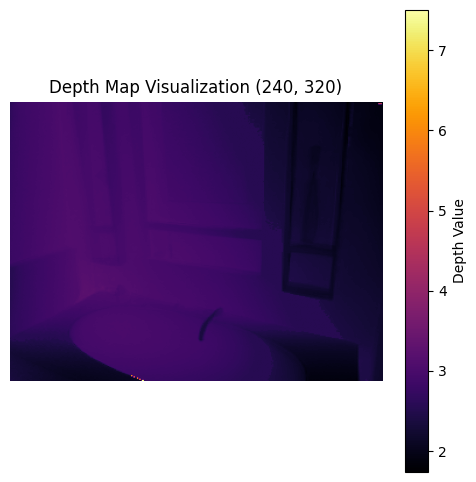

已保存为 depth_heatmap.png


In [6]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 假设这是你的数据加载过程
data = np.load('/data/pre_student/GJ/DepthCAD/test/predict_depth_104_55000.npy')
# 为了演示，我直接使用你提供的形状和大概数值范围生成模拟数据
# data = ... (你已经加载好的变量)

# 2. 检查数据中是否有无穷大 (inf) 或 NaN
# 深度图有时背景是无限远 (inf)，这会导致可视化失败，需要处理一下
if np.isinf(data).any():
    # 将 inf 替换为当前数据中的最大有限值，或者一个特定值
    max_val = data[~np.isinf(data)].max()
    data[np.isinf(data)] = max_val

# 3. 使用 Matplotlib 绘图
plt.figure(figsize=(6, 6))

# cmap 参数决定颜色风格：
# 'viridis' (默认，蓝绿黄), 'inferno' (黑红黄), 'plasma' (紫红黄), 'jet' (彩虹色)
# 'gray' (灰度)
plt.imshow(data, cmap='inferno') 
plt.colorbar(label='Depth Value') # 显示色条，告诉你颜色代表的数值
plt.title(f'Depth Map Visualization {data.shape}')
plt.axis('off') # 不显示坐标轴

# 4. 保存
plt.savefig('depth_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()
print("已保存为 depth_heatmap.png")

In [2]:
import numpy as np
from scipy.io import savemat
IQ = np.load('/data/pre_student/GJ/DepthCAD/pbrt/data_1212/bathroom/1/100.npy')
savemat('IQ.mat', {'IQ': IQ})

from datasets import load_dataset
ds = load_dataset("pbrt_dataset", trust_remote_code=True)
print(ds)
print(ds['train'][0])

In [8]:
import numpy as np
data = np.load('/data/pre_student/hcy/pbrt/gt_depth/bathroom/0/1.npy')
print(data)
print(data.shape) # 查看数组的形状
print(data.dtype) # 查看数组的数据类型


[[2.925159  2.9348788 2.9446635 ... 4.7367463 4.730214  4.723699 ]
 [2.9273696 2.9371047 2.946904  ... 4.7437572 4.7372055 4.730672 ]
 [2.929584  2.9393334 2.9491482 ... 4.7507887 4.744218  4.7376647]
 ...
 [0.        0.        0.        ... 0.        0.        0.       ]
 [0.        0.        0.        ... 0.        0.        0.       ]
 [0.        0.        0.        ... 0.        0.        0.       ]]
(240, 320)
float32


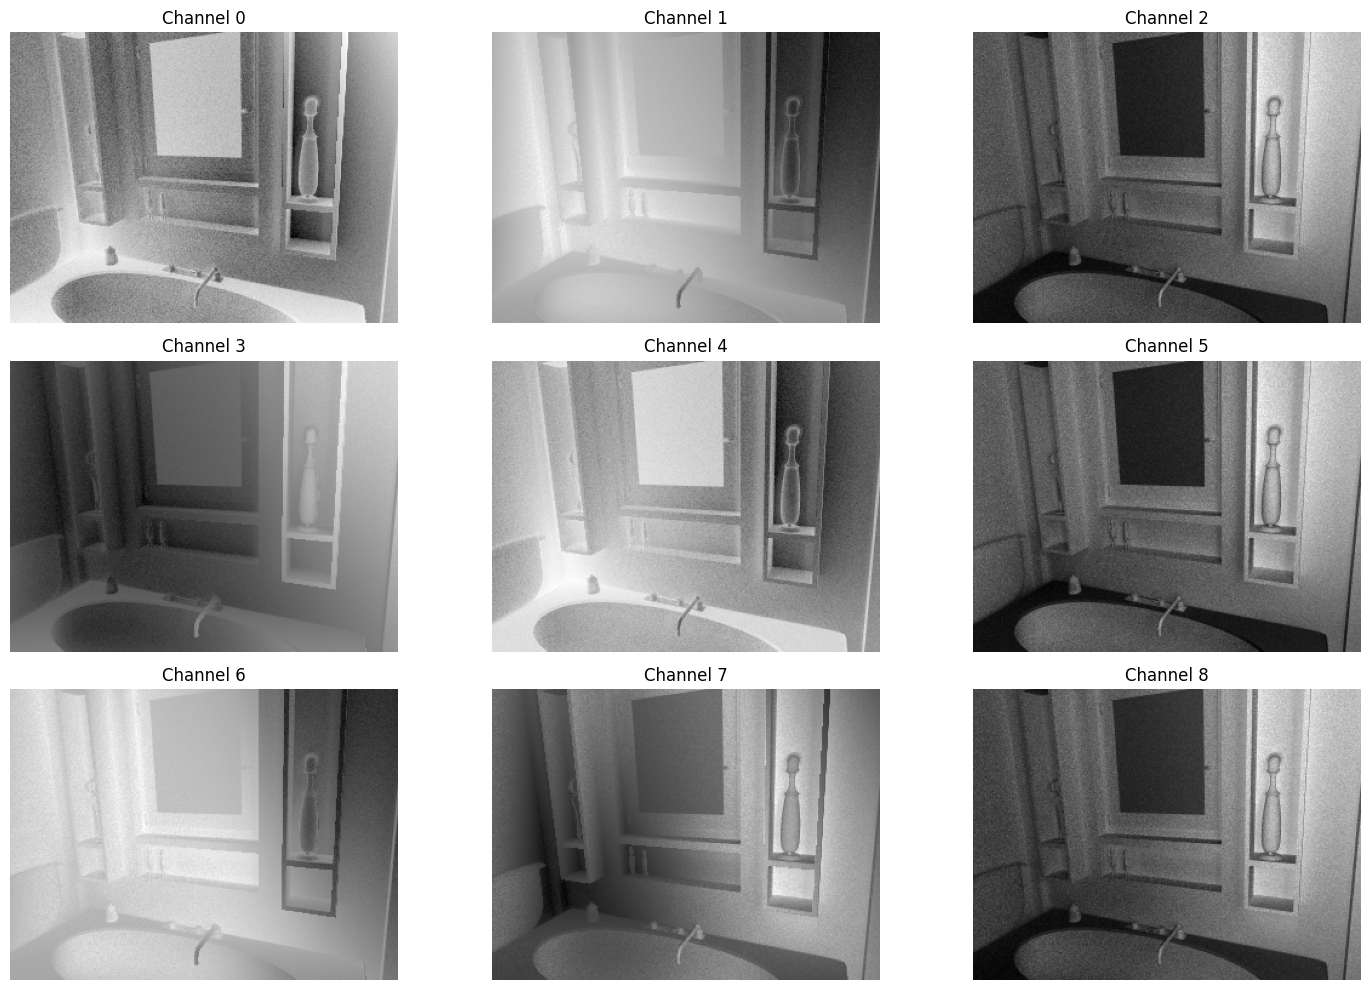

In [3]:
import numpy as np
import matplotlib.pyplot as plt

data = np.load('/data/pre_student/hcy/pbrt/gt/bathroom/1/104.npy')

# 创建一个 3x3 的画布
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten() # 把 3x3 的数组展平，方便循环

for i in range(9):
    # 取出第 i 个通道，形状是 (240, 320)
    channel = data[i, :, :]
    
    # 简单的归一化以便查看细节 (把每个通道单独拉伸到 0-1 显示)
    # 加上 1e-8 防止全0数据除以0报错
    channel_show = (channel - channel.min()) / (channel.max() - channel.min() + 1e-8)
    
    # 显示热力图
    axes[i].imshow(channel_show, cmap='gray') # 使用灰度显示
    axes[i].set_title(f'Channel {i}')
    axes[i].axis('off')

plt.tight_layout()
plt.savefig('all_channels_view.png')
plt.show()

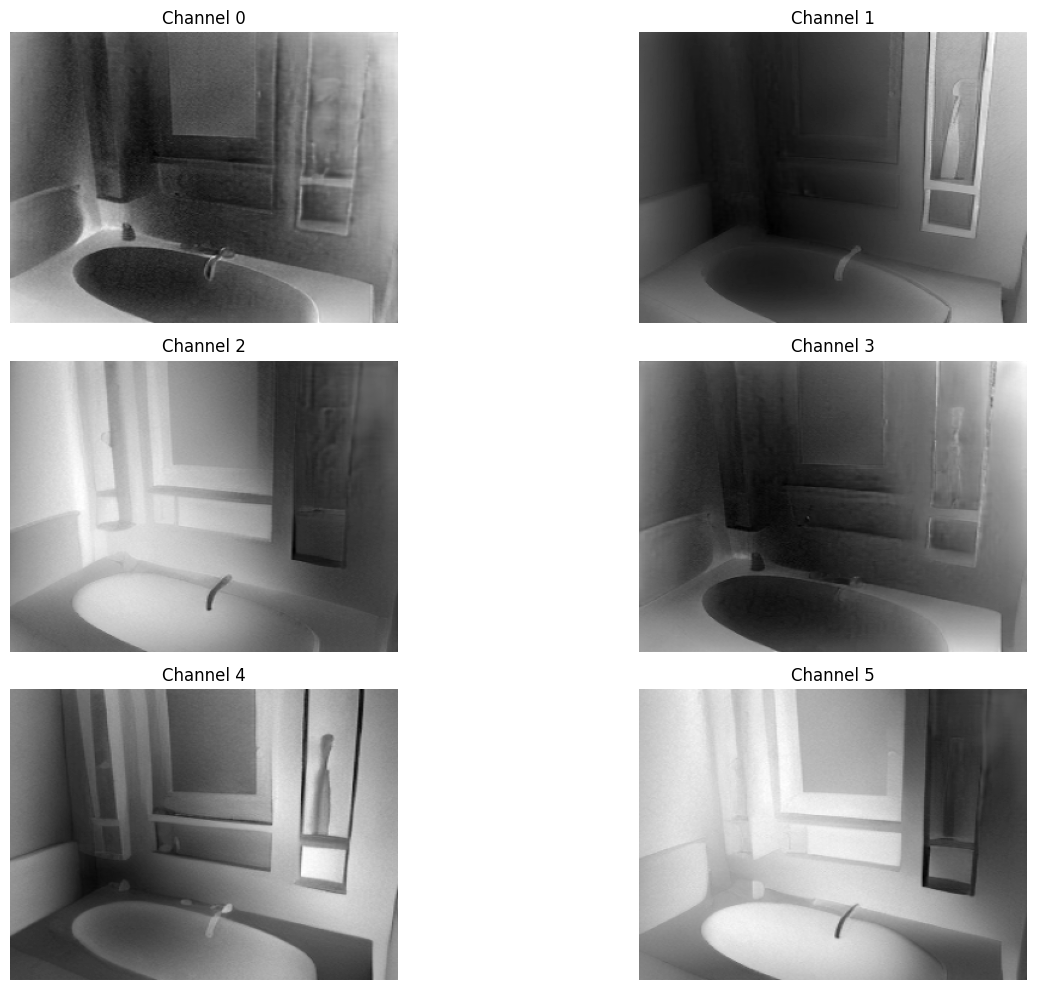

In [4]:
import numpy as np
import matplotlib.pyplot as plt

data = np.load('/data/pre_student/GJ/DepthCAD/pred_IQs.npy')

# 创建一个 3x3 的画布
fig, axes = plt.subplots(3, 2, figsize=(15, 10))
axes = axes.flatten() # 把 3x3 的数组展平，方便循环

for i in range(6):
    # 取出第 i 个通道，形状是 (240, 320)
    channel = data[i, :, :]
    
    # 简单的归一化以便查看细节 (把每个通道单独拉伸到 0-1 显示)
    # 加上 1e-8 防止全0数据除以0报错
    channel_show = (channel - channel.min()) / (channel.max() - channel.min() + 1e-8)
    
    # 显示热力图
    axes[i].imshow(channel_show, cmap='gray') # 使用灰度显示
    axes[i].set_title(f'Channel {i}')
    axes[i].axis('off')

plt.tight_layout()
plt.savefig('all_channels_view.png')
plt.show()

Depth shape: (240, 320)
Depth dtype: float64
Depth range: [1.5083, 3.0466] meters
Saved depth_gray.png
Saved depth_colored.png


/tmp/ipykernel_63968/1590842190.py:39: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('jet')  # 或者 'viridis', 'plasma', 'inferno', 'turbo'


Saved depth_visualization.png


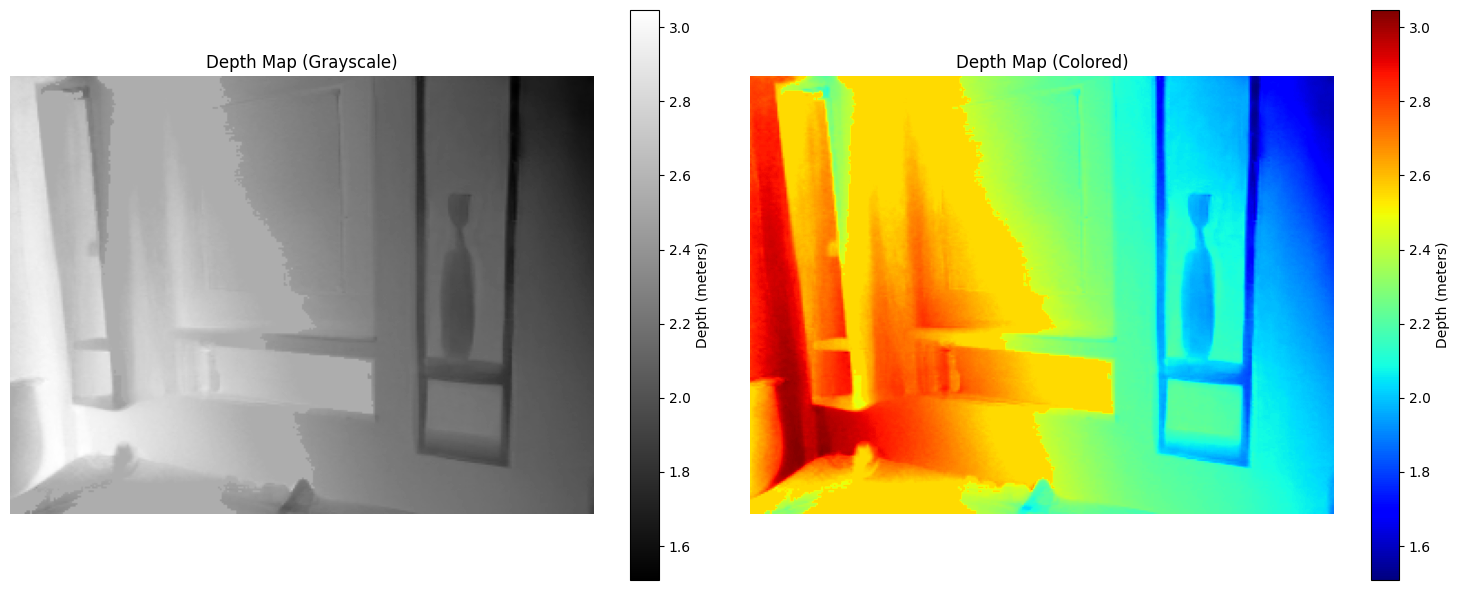


所有图像已保存！


In [2]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# 加载深度图（使用你实际的文件路径）
depth = np.load('/data/pre_student/GJ/DepthCAD/pbrt/data_1212_55000/bathroom/1/101.npy')
print(f"Depth shape: {depth.shape}")
print(f"Depth dtype: {depth.dtype}")
print(f"Depth range: [{depth.min():.4f}, {depth.max():.4f}] meters")

# 方法1: 归一化到 0-255 并保存为灰度图
depth_min = depth.min()
depth_max = depth.max()
depth_range = depth_max - depth_min

if depth_range > 1e-8:  # 避免除以0
    # 归一化到 [0, 1]
    depth_normalized = (depth - depth_min) / depth_range
    # 转换为 0-255 的 uint8
    depth_uint8 = (depth_normalized * 255).astype(np.uint8)
else:
    # 如果深度值几乎相同，设为中等灰度
    depth_uint8 = np.ones_like(depth, dtype=np.uint8) * 128

# 保存为灰度图
img_gray = Image.fromarray(depth_uint8)
img_gray.save('depth_gray.png')
print("Saved depth_gray.png")

# 方法2: 使用伪彩色（colormap）可视化深度
# 归一化深度到 [0, 1]
if depth_range > 1e-8:
    depth_normalized = (depth - depth_min) / depth_range
else:
    depth_normalized = np.ones_like(depth) * 0.5

# 使用 colormap（例如 'jet', 'viridis', 'plasma', 'inferno'）
colormap = cm.get_cmap('jet')  # 或者 'viridis', 'plasma', 'inferno', 'turbo'
depth_colored = colormap(depth_normalized)

# 转换为 0-255 的 uint8
depth_colored_uint8 = (depth_colored[:, :, :3] * 255).astype(np.uint8)

# 保存为彩色图
img_colored = Image.fromarray(depth_colored_uint8)
img_colored.save('depth_colored.png')
print("Saved depth_colored.png")

# 方法3: 使用 matplotlib 显示并保存（带颜色条）
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 灰度图
im1 = axes[0].imshow(depth, cmap='gray')
axes[0].set_title('Depth Map (Grayscale)')
axes[0].axis('off')
plt.colorbar(im1, ax=axes[0], label='Depth (meters)')

# 伪彩色图
im2 = axes[1].imshow(depth, cmap='jet')
axes[1].set_title('Depth Map (Colored)')
axes[1].axis('off')
plt.colorbar(im2, ax=axes[1], label='Depth (meters)')

plt.tight_layout()
plt.savefig('depth_visualization.png', dpi=150, bbox_inches='tight')
print("Saved depth_visualization.png")
plt.show()

print("\n所有图像已保存！")



In [3]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# 加载深度图（使用你实际的文件路径）
depth = np.load('/data/pre_student/hcy/pbrt/gt/bathroom/1/101.npy')
print(f"Depth shape: {depth.shape}")
print(f"Depth dtype: {depth.dtype}")
print(f"Depth range: [{depth.min():.4f}, {depth.max():.4f}] meters")

# 方法1: 归一化到 0-255 并保存为灰度图
depth_min = depth.min()
depth_max = depth.max()
depth_range = depth_max - depth_min

if depth_range > 1e-8:  # 避免除以0
    # 归一化到 [0, 1]
    depth_normalized = (depth - depth_min) / depth_range
    # 转换为 0-255 的 uint8
    depth_uint8 = (depth_normalized * 255).astype(np.uint8)
else:
    # 如果深度值几乎相同，设为中等灰度
    depth_uint8 = np.ones_like(depth, dtype=np.uint8) * 128

# 保存为灰度图
img_gray = Image.fromarray(depth_uint8)
img_gray.save('depth_gray.png')
print("Saved depth_gray.png")

# 方法2: 使用伪彩色（colormap）可视化深度
# 归一化深度到 [0, 1]
if depth_range > 1e-8:
    depth_normalized = (depth - depth_min) / depth_range
else:
    depth_normalized = np.ones_like(depth) * 0.5

# 使用 colormap（例如 'jet', 'viridis', 'plasma', 'inferno'）
colormap = cm.get_cmap('jet')  # 或者 'viridis', 'plasma', 'inferno', 'turbo'
depth_colored = colormap(depth_normalized)

# 转换为 0-255 的 uint8
depth_colored_uint8 = (depth_colored[:, :, :3] * 255).astype(np.uint8)

# 保存为彩色图
img_colored = Image.fromarray(depth_colored_uint8)
img_colored.save('depth_colored.png')
print("Saved depth_colored.png")

# 方法3: 使用 matplotlib 显示并保存（带颜色条）
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 灰度图
im1 = axes[0].imshow(depth, cmap='gray')
axes[0].set_title('Depth Map (Grayscale)')
axes[0].axis('off')
plt.colorbar(im1, ax=axes[0], label='Depth (meters)')

# 伪彩色图
im2 = axes[1].imshow(depth, cmap='jet')
axes[1].set_title('Depth Map (Colored)')
axes[1].axis('off')
plt.colorbar(im2, ax=axes[1], label='Depth (meters)')

plt.tight_layout()
plt.savefig('depth_visualization.png', dpi=150, bbox_inches='tight')
print("Saved depth_visualization.png")
plt.show()

print("\n所有图像已保存！")



Depth shape: (9, 240, 320)
Depth dtype: float64
Depth range: [-452.0019, 500.0000] meters


TypeError: Cannot handle this data type: (1, 1, 320), |u1

In [2]:
import numpy as np
from PIL import Image

# 1. 加载数据
arr = np.load('/data/pre_student/GJ/DepthCAD/pbrt/data_1212/bathroom/1/101.npy')
print(f"原始数据 - Shape: {arr.shape}, Dtype: {arr.dtype}")
print(f"数值范围: [{arr.min():.6f}, {arr.max():.6f}]")

# --- 预处理步骤 ---
# 情况 A: 如果数据是 (Channel, Height, Width) -> 转为 (Height, Width, Channel)
if arr.ndim == 3 and arr.shape[0] in [1, 3]: 
    arr = arr.transpose(1, 2, 0)
    print(f"转置后 - Shape: {arr.shape}")

# 情况 B: 将float数据归一化到[0, 1]范围，然后转为0-255的整数
if arr.dtype == np.float32 or arr.dtype == np.float64:
    # 方法1: 线性归一化到[0, 1]
    arr_min = arr.min()
    arr_max = arr.max()
    arr_range = arr_max - arr_min
    
    if arr_range > 1e-8:  # 避免除以0
        # 归一化到[0, 1]
        arr_normalized = (arr - arr_min) / arr_range
    else:
        # 如果数据范围太小，直接设为0.5
        arr_normalized = np.ones_like(arr) * 0.5
    
    print(f"归一化后范围: [{arr_normalized.min():.6f}, {arr_normalized.max():.6f}]")
    
    # 转换为0-255的uint8
    arr = (arr_normalized * 255).astype(np.uint8)
    print(f"转换为uint8后范围: [{arr.min()}, {arr.max()}]")

# 情况 C: 如果是单通道 (H, W, 1) -> 降维成 (H, W)
if arr.ndim == 3 and arr.shape[2] == 1:
    arr = arr.squeeze()
    print(f"降维后 - Shape: {arr.shape}")

# 2. 转为图像对象
# 如果是灰度图/深度图
if arr.ndim == 2:
    img = Image.fromarray(arr)  # PIL会自动识别为灰度图
    print(f"创建图像 - Mode: {img.mode}, Size: {img.size}")
# 如果是 RGB
else:
    img = Image.fromarray(arr)

# 3. 保存
img.save('output.png')
print("保存成功！")

原始数据 - Shape: (256, 256), Dtype: float64
数值范围: [2.600520, 9.571914]
归一化后范围: [0.000000, 1.000000]
转换为uint8后范围: [0, 255]
创建图像 - Mode: L, Size: (256, 256)
保存成功！


In [4]:
import numpy as np
from PIL import Image
# import matplotlib.pyplot as plt
# import matplotlib.cm as cm

# 加载深度图
depth = np.load('/data/pre_student/GJ/DepthCAD/pbrt/data_1212/bathroom/1/100.npy')  # 替换为你的文件路径
print(f"Depth shape: {depth.shape}")
print(f"Depth dtype: {depth.dtype}")
print(f"Depth range: [{depth.min():.4f}, {depth.max():.4f}] meters")

# 方法1: 归一化到 0-255 并保存为灰度图
depth_min = depth.min()
depth_max = depth.max()
depth_range = depth_max - depth_min

if depth_range > 1e-8:  # 避免除以0
    # 归一化到 [0, 1]
    depth_normalized = (depth - depth_min) / depth_range
    # 转换为 0-255 的 uint8
    depth_uint8 = (depth_normalized * 255).astype(np.uint8)
else:
    # 如果深度值几乎相同，设为中等灰度
    depth_uint8 = np.ones_like(depth, dtype=np.uint8) * 128
# 保存为灰度图
img_gray = Image.fromarray(depth_uint8)
img_gray.save('depth_gray.png')
print("Saved depth_gray.png")


Depth shape: (256, 256)
Depth dtype: float64
Depth range: [2.6825, 9.6319] meters
Saved depth_gray.png


In [7]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.cm as cm
if depth_range > 1e-8:
    depth_normalized = (depth - depth_min) / depth_range
else:
    depth_normalized = np.ones_like(depth) * 0.5

# 使用 colormap（例如 'jet', 'viridis', 'plasma', 'inferno'）
colormap = cm.get_cmap('jet')  # 或者 'viridis', 'plasma', 'inferno', 'turbo'
depth_colored = colormap(depth_normalized)

# 转换为 0-255 的 uint8
depth_colored_uint8 = (depth_colored[:, :, :3] * 255).astype(np.uint8)

# 保存为彩色图
img_colored = Image.fromarray(depth_colored_uint8)
img_colored.save('depth_colored.png')
print("Saved depth_colored.png")

Saved depth_colored.png


/tmp/ipykernel_2312038/2239644717.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = cm.get_cmap('jet')  # 或者 'viridis', 'plasma', 'inferno', 'turbo'


In [ ]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# 加载深度图
depth = np.load('/path/to/your/depth.npy')  # 替换为你的文件路径
print(f"Depth shape: {depth.shape}")
print(f"Depth dtype: {depth.dtype}")
print(f"Depth range: [{depth.min():.4f}, {depth.max():.4f}] meters")

# 方法1: 归一化到 0-255 并保存为灰度图
depth_min = depth.min()
depth_max = depth.max()
depth_range = depth_max - depth_min

if depth_range > 1e-8:  # 避免除以0
    # 归一化到 [0, 1]
    depth_normalized = (depth - depth_min) / depth_range
    # 转换为 0-255 的 uint8
    depth_uint8 = (depth_normalized * 255).astype(np.uint8)
else:
    # 如果深度值几乎相同，设为中等灰度
    depth_uint8 = np.ones_like(depth, dtype=np.uint8) * 128

# 保存为灰度图
img_gray = Image.fromarray(depth_uint8)
img_gray.save('depth_gray.png')
print("Saved depth_gray.png")

# 方法2: 使用伪彩色（colormap）可视化深度
# 归一化深度到 [0, 1]
if depth_range > 1e-8:
    depth_normalized = (depth - depth_min) / depth_range
else:
    depth_normalized = np.ones_like(depth) * 0.5

# 使用 colormap（例如 'jet', 'viridis', 'plasma', 'inferno'）
colormap = cm.get_cmap('jet')  # 或者 'viridis', 'plasma', 'inferno', 'turbo'
depth_colored = colormap(depth_normalized)

# 转换为 0-255 的 uint8
depth_colored_uint8 = (depth_colored[:, :, :3] * 255).astype(np.uint8)

# 保存为彩色图
img_colored = Image.fromarray(depth_colored_uint8)
img_colored.save('depth_colored.png')
print("Saved depth_colored.png")

# 方法3: 使用 matplotlib 显示并保存（带颜色条）
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 灰度图
im1 = axes[0].imshow(depth, cmap='gray')
axes[0].set_title('Depth Map (Grayscale)')
axes[0].axis('off')
plt.colorbar(im1, ax=axes[0], label='Depth (meters)')

# 伪彩色图
im2 = axes[1].imshow(depth, cmap='jet')
axes[1].set_title('Depth Map (Colored)')
axes[1].axis('off')
plt.colorbar(im2, ax=axes[1], label='Depth (meters)')

plt.tight_layout()
plt.savefig('depth_visualization.png', dpi=150, bbox_inches='tight')
print("Saved depth_visualization.png")
plt.show()

print("\n所有图像已保存！")
